In [90]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import norm
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

In [43]:
spx = pd.read_csv("data/processed/SPX_cleaned.csv")
spx["date"] = pd.to_datetime(spx["date"])
spx["exdate"] = pd.to_datetime(spx["exdate"])

print(spx.shape)
spx.head()

(7688150, 17)


,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price,volatility,rate,days_to_maturity,T,q
0,108105,2020-08-31,2020-09-18,100.0,3402.5,3408.2,0,611,133485146,3500.31,35.003100,3405.35,0.111899,0.002148,18,0.049315,0.01589
1,108105,2020-08-31,2020-09-18,1000.0,2503.2,2508.0,0,37663,130915017,3500.31,3.500310,2505.60,0.111899,0.002148,18,0.049315,0.01589
2,108105,2020-08-31,2020-09-18,1100.0,2403.4,2407.9,0,96,130915018,3500.31,3.182100,2405.65,0.111899,0.002148,18,0.049315,0.01589
3,108105,2020-08-31,2020-09-18,1200.0,2303.5,2307.9,0,19,129372797,3500.31,2.916925,2305.70,0.111899,0.002148,18,0.049315,0.01589
4,108105,2020-08-31,2020-09-18,1250.0,2253.7,2258.0,0,20,129372798,3500.31,2.800248,2255.85,0.111899,0.002148,18,0.049315,0.01589


### Black-Scholes benchmark (call formula)

The closed-form Black-Scholes price is computed for each option as the benchmark against which the machine learning models will later be compared. Since the analysis is restricted to call options, only the call formula is implemented:

C = S·e^(-qT)·N(d1) − K·e^(-rT)·N(d2)

d1 = [ln(S/K) + (r − q + σ²/2)T] / (σ√T)

d2 = d1 − σ√T

In [44]:
d1 = (
    np.log(spx["close"] / spx["strike_price"])
    + (spx["rate"] - spx["q"] + 0.5 * spx["volatility"] ** 2) * spx["T"]
) / (spx["volatility"] * np.sqrt(spx["T"]))

d2 = d1 - spx["volatility"] * np.sqrt(spx["T"])

In [45]:
spx["bs_price"] = (
    spx["close"] * np.exp(-spx["q"] * spx["T"]) * norm.cdf(d1)
    - spx["strike_price"] * np.exp(-spx["rate"] * spx["T"]) * norm.cdf(d2)
)

spx["bs_price"].describe()

count    7.688150e+06
mean     4.168183e+02
std      6.769914e+02
min      0.000000e+00
25%      3.834214e+01
50%      1.692638e+02
75%      4.849242e+02
max      6.298850e+03
Name: bs_price, dtype: float64

In [46]:
spx["bs_error"] = spx["price"] - spx["bs_price"]

print(spx["bs_error"].describe())

count    7.688150e+06
mean     6.311162e+00
std      4.028861e+01
min     -5.092495e+02
25%     -2.365354e+00
50%      3.056414e+00
75%      1.875544e+01
max      2.442015e+02
Name: bs_error, dtype: float64


Black-Scholes shows a small positive mean error (+6.31 points) on the full SPX dataset, indicating a slight systematic underpricing relative to observed market prices — consistent with the AAPL benchmark (+0.15$) and with a more pronounced volatility skew typically observed on index options. The standard deviation (40.29) is far larger than the mean, confirming that this aggregate figure is not representative on its own; the moneyness-bucket breakdown (see diagnostic below) is needed to interpret it correctly

In [47]:
print(spx.nlargest(5, "bs_error")[["date", "moneyness (S/K)", "T", "volatility", "price", "bs_price", "bs_error"]])
print()
print(spx.nsmallest(5, "bs_error")[["date", "moneyness (S/K)", "T", "volatility", "price", "bs_price", "bs_error"]])

              date  moneyness (S/K)         T  volatility    price  \
6909729 2025-04-08         4.982770  0.871233    0.254580  4228.70   
1581116 2021-11-30         1.026292  0.832877    0.120429   480.10   
6909732 2025-04-08        24.913850  0.871233    0.254580  4996.50   
6909734 2025-04-08        12.456925  0.871233    0.254580  4803.85   
6909833 2025-04-08         4.982770  0.947945    0.254580  4224.35   

            bs_price    bs_error  
6909729  3984.498451  244.201549  
1581116   237.725216  242.374784  
6909732  4754.383026  242.116974  
6909734  4561.911882  241.938118  
6909833  3984.594397  239.755603  

              date  moneyness (S/K)         T  volatility   price    bs_price  \
7189407 2025-05-27         0.887122  0.967123    0.369738  135.65  644.899532   
7189408 2025-05-27         0.883812  0.967123    0.369738  127.80  636.856188   
7189406 2025-05-27         0.890457  0.967123    0.369738  144.00  653.033047   
7189405 2025-05-27         0.893817  0.96712

### Diagnostic: Black-Scholes error by moneyness bucket

Before introducing any machine learning model, the Black-Scholes benchmark error is broken down by moneyness bucket on the validation set. This step is diagnostic: it checks whether the very low *aggregate* Black-Scholes error (computed above) is genuinely representative, or whether it is an artifact of the dataset composition (e.g. a large share of deep in-the-money contracts, for which price is close to intrinsic value and therefore near-trivial to predict).

In [48]:
spx_check = spx.copy()
spx_check["bs_error_abs"] = np.abs(spx_check["price"] - spx_check["bs_price"])

bins = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
labels = ["deep OTM", "OTM", "ATM", "ITM", "deep ITM", "very deep ITM", "extreme ITM"]
spx_check["moneyness_bucket"] = pd.cut(spx_check["moneyness (S/K)"], bins=bins, labels=labels)

print(spx_check.groupby("moneyness_bucket")["bs_error_abs"].agg(["mean", "count"]))

                       mean    count
moneyness_bucket                    
deep OTM          11.970271   207164
OTM               19.677043  1420639
ATM               22.831425  3204113
ITM               27.552925  1774497
deep ITM          17.385941   854516
very deep ITM      5.010267   166181
extreme ITM        3.993765    61040


Percentage error

In [49]:
spx_check["bs_pct_error"] = spx_check["bs_error_abs"] / spx_check["price"] * 100
print(spx_check.groupby("moneyness_bucket")["bs_pct_error"].agg(["mean", "count"]))

                        mean    count
moneyness_bucket                     
deep OTM          812.801643   207164
OTM               237.316819  1420639
ATM                45.853113  3204113
ITM                 5.369066  1774497
deep ITM            1.513932   854516
very deep ITM       0.187511   166181
extreme ITM         0.096763    61040


As with AAPL, the percentage error is structurally unstable and inflated on low-price buckets (deep OTM/OTM), where a modest absolute error is divided by a very small real price, producing values that overstate the practical mispricing. The absolute error is more informative in that region, but must be read relative to the underlying's price scale when comparing directly across AAPL and SPX. Both metrics are reported side by side for this reason.

### Dataset split

In [50]:
spx = spx.sort_values("date").reset_index(drop=True)

train_cutoff = spx["date"].quantile(0.70)
val_cutoff = spx["date"].quantile(0.85)

train = spx[spx["date"] <= train_cutoff]
val = spx[(spx["date"] > train_cutoff) & (spx["date"] <= val_cutoff)]
test = spx[spx["date"] > val_cutoff]

print(f"Train: {len(train)} rows, {train['date'].min()} to {train['date'].max()}")
print(f"Validation: {len(val)} rows, {val['date'].min()} to {val['date'].max()}")
print(f"Test: {len(test)} rows, {test['date'].min()} to {test['date'].max()}")

Train: 5388081 rows, 2020-08-31 00:00:00 to 2024-06-04 00:00:00
Validation: 1149725 rows, 2024-06-05 00:00:00 to 2025-01-24 00:00:00
Test: 1150344 rows, 2025-01-27 00:00:00 to 2025-08-29 00:00:00


In [51]:
feature_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
target_col = "price"

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print("Feature columns:", feature_cols)
print("Target column:", target_col)

Feature columns: ['moneyness (S/K)', 'T', 'rate', 'q', 'volatility']
Target column: price


### XGBoost baseline model

A gradient-boosted tree model (XGBoost) is trained on the chronological training set, using the validation set for early stopping to prevent overfitting. Default/simple hyperparameters are used for this initial baseline; tuning is deferred to a later iteration.

This first model (baseline) uses the same five inputs as the Black-Scholes benchmark, with the raw option price as target.

In [52]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Best iteration: {model.best_iteration}")
print(f"Best validation RMSE: {model.best_score:.4f}")

Best iteration: 16
Best validation RMSE: 206.6847


In [53]:
val_pred = model.predict(X_val)

val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_mae = mean_absolute_error(y_val, val_pred)
val_r2 = r2_score(y_val, val_pred)

print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation R²: {val_r2:.4f}")

Validation RMSE: 206.6847
Validation MAE: 103.0741
Validation R²: 0.9288


In [54]:
# Baseline XGBoost vs Black-Scholes — error by moneyness bucket (validation set)
val_check_baseline = val.copy()
val_check_baseline["xgb_baseline_pred"] = val_pred
val_check_baseline["xgb_baseline_error_abs"] = (val_check_baseline["price"] - val_check_baseline["xgb_baseline_pred"]).abs()
val_check_baseline["bs_error_abs"] = (val_check_baseline["price"] - val_check_baseline["bs_price"]).abs()

val_check_baseline["moneyness_bucket"] = pd.cut(
    val_check_baseline["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["deep OTM", "OTM", "ATM", "ITM", "deep ITM", "very deep ITM", "extreme ITM"]
)

val_check_baseline.groupby("moneyness_bucket")[["bs_error_abs", "xgb_baseline_error_abs"]].agg(["mean", "count"])

bs_error_abs         xgb_baseline_error_abs        
                         mean   count                   mean   count
moneyness_bucket                                                    
deep OTM             2.604380   21332               3.250542   21332
OTM                 13.499352  157667               7.722491  157667
ATM                 20.036567  529060              28.267466  529060
ITM                 24.450231  272607             125.309977  272607
deep ITM            15.347653  143006             325.457674  143006
very deep ITM        5.612540   17812             704.557545   17812
extreme ITM          5.339505    8241            1093.608979    8241

### Experiment (v2): separate S and K, log-transformed target

This configuration replaces moneyness with the underlying price and strike as separate inputs, and switches the target to `log1p(price)` (predictions are converted back with `expm1`). It is compared against Black-Scholes by moneyness bucket, both in absolute and percentage error.

In [55]:
feature_cols_v2 = ["close", "strike_price", "T", "rate", "q", "volatility"]

X_train_v2, X_val_v2 = train[feature_cols_v2], val[feature_cols_v2]

y_train_log = np.log1p(train["price"])
y_val_log = np.log1p(val["price"])

In [56]:
model_v2 = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)

model_v2.fit(X_train_v2, y_train_log, eval_set=[(X_val_v2, y_val_log)], verbose=False)

print(f"Best iteration: {model_v2.best_iteration}")

Best iteration: 1


In [57]:
val_pred_v2 = np.expm1(model_v2.predict(X_val_v2))

rmse_v2 = np.sqrt(mean_squared_error(val["price"], val_pred_v2))
mae_v2 = mean_absolute_error(val["price"], val_pred_v2)

print(f"XGBoost v2 — RMSE: {rmse_v2:.4f}, MAE: {mae_v2:.4f}")

val_check = val.copy()
val_check["xgb_v2_error_abs"] = np.abs(val_check["price"] - val_pred_v2)
val_check["bs_error_abs"] = np.abs(val_check["price"] - val_check["bs_price"])

bins = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
labels = ["deep OTM", "OTM", "ATM", "ITM", "deep ITM", "very deep ITM", "extreme ITM"]
val_check["moneyness_bucket"] = pd.cut(val_check["moneyness (S/K)"], bins=bins, labels=labels)

print(val_check.groupby("moneyness_bucket")[["bs_error_abs", "xgb_v2_error_abs"]].agg(["mean", "count"]))

XGBoost v2 — RMSE: 784.9173, MAE: 427.4357
                 bs_error_abs         xgb_v2_error_abs        
                         mean   count             mean   count
moneyness_bucket                                              
deep OTM             2.604380   21332        29.581112   21332
OTM                 13.499352  157667        27.852104  157667
ATM                 20.036567  529060       123.083317  529060
ITM                 24.450231  272607       525.504286  272607
deep ITM            15.347653  143006      1299.033133  143006
very deep ITM        5.612540   17812      3107.381447   17812
extreme ITM          5.339505    8241      4479.832961    8241


Across every moneyness bucket, XGBoost v2 (S and K as separate inputs, log-transformed target) performs substantially worse than the baseline (moneyness as a single input, raw price target) — roughly 4x worse absolute error almost uniformly, and nearly 10x worse on deep OTM. This is consistent with the hypothesis that dropping moneyness in favor of raw S and K removes the normalization that lets the model generalize across price levels. The effect is particularly severe here because SPX's price level nearly doubles over the sample period (from ~3,200 to ~6,500), so training on absolute S and K values leaves the model with limited ability to extrapolate to the price range seen later in the validation set — independent of the log-transformation applied to the target. This result reinforces, on a second and independent dataset, the methodological choice of using moneyness (S/K) rather than S and K separately, consistent with Hutchinson, Lo & Poggio (1994) and Garcia & Gençay (2000).

In [58]:
# Black-Scholes, normalized (C/X)
bs_pred_norm = val["bs_price"] / val["strike_price"]

# XGBoost v2, normalized (C/X)
xgb_pred_norm = val_pred_v2 / val["strike_price"]

# True target, normalized (C/X)
true_norm = val["price"] / val["strike_price"]

bs_r2_norm = r2_score(true_norm, bs_pred_norm)
xgb_r2_norm = r2_score(true_norm, xgb_pred_norm)

bs_rmse_norm = np.sqrt(mean_squared_error(true_norm, bs_pred_norm))
xgb_rmse_norm = np.sqrt(mean_squared_error(true_norm, xgb_pred_norm))

print(f"Black-Scholes — R² (C/X): {bs_r2_norm:.4f}, RMSE (C/X): {bs_rmse_norm:.4f}")
print(f"XGBoost       — R² (C/X): {xgb_r2_norm:.4f}, RMSE (C/X): {xgb_rmse_norm:.4f}")

Black-Scholes — R² (C/X): 1.0000, RMSE (C/X): 0.0057
XGBoost       — R² (C/X): 0.2100, RMSE (C/X): 1.2020


In [59]:
reasonable_mask = val["moneyness (S/K)"].between(0.7, 1.3)

bs_r2_reasonable = r2_score(val.loc[reasonable_mask, "price"], val.loc[reasonable_mask, "bs_price"])
xgb_r2_reasonable = r2_score(val.loc[reasonable_mask, "price"], val_pred_v2[reasonable_mask.values])

print(f"Righe nel range 0.7-1.3 moneyness: {reasonable_mask.sum()} su {len(val)}")
print(f"Black-Scholes — R² (moneyness 0.7-1.3): {bs_r2_reasonable:.4f}")
print(f"XGBoost       — R² (moneyness 0.7-1.3): {xgb_r2_reasonable:.4f}")

Righe nel range 0.7-1.3 moneyness: 1038898 su 1149725
Black-Scholes — R² (moneyness 0.7-1.3): 0.9924
XGBoost       — R² (moneyness 0.7-1.3): -0.2769


In [60]:
val_check["xgb_v2_pct_error"] = val_check["xgb_v2_error_abs"] / val_check["price"] * 100
val_check["bs_pct_error"] = val_check["bs_error_abs"] / val_check["price"] * 100

print(val_check.groupby("moneyness_bucket")[["bs_pct_error", "xgb_v2_pct_error"]].mean())

                  bs_pct_error  xgb_v2_pct_error
moneyness_bucket                                
deep OTM            167.997662       8507.219274
OTM                 127.199891       2744.013408
ATM                  47.068265        535.090533
ITM                   3.876714         84.403889
deep ITM              1.077628         81.461525
very deep ITM         0.157593         85.406861
extreme ITM           0.103947         87.346619


### Best configuration (v3): moneyness input + log-transformed target

This configuration keeps the same five inputs as the baseline (moneyness in place of S and K separately) but switches the target to `log1p(price)`, as in v2. Of the configurations tested, this is the one retained as the current XGBoost baseline for further work (hyperparameter tuning, SPX comparison, etc.).

In [61]:
feature_cols_v3 = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
X_train_v3, X_val_v3 = train[feature_cols_v3], val[feature_cols_v3]

model_v3 = xgb.XGBRegressor(
    n_estimators=1000, 
    early_stopping_rounds=50, 
    eval_metric="rmse", 
    random_state=42
)
model_v3.fit(X_train_v3, y_train_log, eval_set=[(X_val_v3, y_val_log)], verbose=False)

val_pred_v3 = np.expm1(model_v3.predict(X_val_v3))
val_check["xgb_v3_pct_error"] = np.abs(val_check["price"] - val_pred_v3) / val_check["price"] * 100

print(val_check.groupby("moneyness_bucket")[["bs_pct_error", "xgb_v3_pct_error"]].mean())

                  bs_pct_error  xgb_v3_pct_error
moneyness_bucket                                
deep OTM            167.997662         81.954585
OTM                 127.199891         56.649601
ATM                  47.068265         37.879540
ITM                   3.876714         19.382424
deep ITM              1.077628         19.828697
very deep ITM         0.157593         21.879116
extreme ITM           0.103947         22.823226


In [62]:
val_check["xgb_v3_error_abs"] = np.abs(val_check["price"] - val_pred_v3)

print(val_check.groupby("moneyness_bucket")[["bs_error_abs", "xgb_v3_error_abs"]].agg(["mean", "count"]))

                 bs_error_abs         xgb_v3_error_abs        
                         mean   count             mean   count
moneyness_bucket                                              
deep OTM             2.604380   21332         0.547672   21332
OTM                 13.499352  157667         5.835467  157667
ATM                 20.036567  529060        26.166115  529060
ITM                 24.450231  272607       122.374276  272607
deep ITM            15.347653  143006       321.679254  143006
very deep ITM        5.612540   17812       804.800049   17812
extreme ITM          5.339505    8241      1184.988305    8241


Il log-target non è una soluzione universale al problema di estrapolazione — la sua efficacia dipende da quanto il sottostante si è mosso rispetto al periodo di training, in una frase semplice: il log-target aiuta a "comprimere" la scala dei prezzi, ma non risolve il problema di fondo se il salto tra training e validation è troppo grande — e su SPX quel salto è più grande che su AAPL, perché l'indice si è mosso di più in proporzione nello stesso arco di tempo.

## v4

In [86]:
feature_cols_v4 = ["moneyness (S/K)", "strike_price", "T", "rate", "q", "volatility"]
X_train_v4, X_val_v4 = train[feature_cols_v4], val[feature_cols_v4]

model_v4 = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)
model_v4.fit(X_train_v4, y_train_log, eval_set=[(X_val_v4, y_val_log)], verbose=False)

val_pred_v4 = np.expm1(model_v4.predict(X_val_v4))

v4_check = val.copy()
v4_check["xgb_v4_error_abs"] = np.abs(v4_check["price"] - val_pred_v4)
v4_check["bs_error_abs"] = np.abs(v4_check["price"] - v4_check["bs_price"])

v4_check["moneyness_bucket"] = pd.cut(
    v4_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

xgb_v4_bucket_summary = v4_check.groupby("moneyness_bucket").agg(
    n_options=("xgb_v4_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    xgb_v4_mae=("xgb_v4_error_abs", "mean"),
)
xgb_v4_bucket_summary["ratio_v4_vs_bs"] = xgb_v4_bucket_summary["xgb_v4_mae"] / xgb_v4_bucket_summary["bs_mae"]

xgb_v4_bucket_summary

,n_options,bs_mae,xgb_v4_mae,ratio_v4_vs_bs
moneyness_bucket,,,,
Deep OTM,21332,2.604380,0.386005,0.148214
OTM,157667,13.499352,6.717109,0.497587
ATM,529060,20.036567,27.603253,1.377644
ITM,272607,24.450231,109.112820,4.462650
Deep ITM,143006,15.347653,316.921652,20.649519
Very Deep ITM,17812,5.612540,905.728309,161.375820
Extreme ITM,8241,5.339505,1378.956840,258.255549


## v5 - normalized target price/K

In [87]:
# v5: same 5 inputs as v3, but target normalized by strike — log1p(price / K)
feature_cols_v5 = ["moneyness (S/K)", "T", "rate", "q", "volatility"]

X_train_v5 = train[feature_cols_v5]
X_val_v5 = val[feature_cols_v5]

y_train_ratio_log = np.log1p(train["price"].values / train["strike_price"].values)
y_val_ratio_log = np.log1p(val["price"].values / val["strike_price"].values)

model_v5 = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)
model_v5.fit(X_train_v5, y_train_ratio_log, eval_set=[(X_val_v5, y_val_ratio_log)], verbose=False)

# invert: expm1 gives price/K, then multiply back by K
val_pred_v5 = np.expm1(model_v5.predict(X_val_v5)) * val["strike_price"].values

v5_check = val.copy()
v5_check["xgb_v5_pred"] = val_pred_v5
v5_check["xgb_v5_error_abs"] = np.abs(v5_check["price"] - v5_check["xgb_v5_pred"])
v5_check["bs_error_abs"] = np.abs(v5_check["price"] - v5_check["bs_price"])

v5_check["moneyness_bucket"] = pd.cut(
    v5_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

xgb_v5_bucket_summary = v5_check.groupby("moneyness_bucket").agg(
    n_options=("xgb_v5_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    xgb_v5_mae=("xgb_v5_error_abs", "mean"),
)
xgb_v5_bucket_summary["ratio_v5_vs_bs"] = xgb_v5_bucket_summary["xgb_v5_mae"] / xgb_v5_bucket_summary["bs_mae"]

xgb_v5_bucket_summary

,n_options,bs_mae,xgb_v5_mae,ratio_v5_vs_bs
moneyness_bucket,,,,
Deep OTM,21332,2.604380,6.716026,2.578743
OTM,157667,13.499352,13.556043,1.004200
ATM,529060,20.036567,16.093506,0.803207
ITM,272607,24.450231,14.434824,0.590376
Deep ITM,143006,15.347653,26.655631,1.736789
Very Deep ITM,17812,5.612540,210.601009,37.523295
Extreme ITM,8241,5.339505,1424.004873,266.692292


abbiamo testato se imporre l'omogeneità tramite normalizzazione del target modifichi il pattern: sì nei bucket centrali, no nella coda estrema; questo isola la causa del fallimento deep-ITM come strutturale agli alberi e non attribuibile alla sola formulazione del target.

## Systematic hyperparameter tuning via rolling-window cross-validation

Grid search over XGBoost hyperparameters, evaluated with rolling-window (walk-forward) cross-validation to preserve chronological ordering and avoid look-ahead bias, per Ruf & Wang (2021). Cross-validation is performed only within the combined train+validation period (85% of dates); the held-out test set remains untouched until the final evaluation.

Window design: 24-month training window, 6-month validation window, 6-month step (non-overlapping validation folds). Features and target follow the best configuration found above (v6): moneyness, T, rate, q, volatility, with `log1p(price)` as target.

In [64]:
# Build rolling-window folds: 24-month train, 6-month validation, 6-month step
train_val = pd.concat([train, val]).sort_values("date").reset_index(drop=True)

start_date = train_val["date"].min()
end_date = train_val["date"].max()

fold_boundaries = []
fold_start = start_date

while True:
    train_end = fold_start + pd.DateOffset(months=24)
    if train_end >= end_date:
        break

    val_end = min(train_end + pd.DateOffset(months=6), end_date)
    fold_boundaries.append((fold_start, train_end, val_end))

    if val_end >= end_date:
        break

    fold_start = fold_start + pd.DateOffset(months=6)

print(f"Number of folds: {len(fold_boundaries)}")
for i, (ts, te, ve) in enumerate(fold_boundaries):
    n_val_days = (ve - te).days
    print(f"Fold {i+1}: train [{ts.date()} -> {te.date()}], val [{te.date()} -> {ve.date()}] ({n_val_days} days)")

Number of folds: 5
Fold 1: train [2020-08-31 -> 2022-08-31], val [2022-08-31 -> 2023-02-28] (181 days)
Fold 2: train [2021-02-28 -> 2023-02-28], val [2023-02-28 -> 2023-08-28] (181 days)
Fold 3: train [2021-08-28 -> 2023-08-28], val [2023-08-28 -> 2024-02-28] (184 days)
Fold 4: train [2022-02-28 -> 2024-02-28], val [2024-02-28 -> 2024-08-28] (182 days)
Fold 5: train [2022-08-28 -> 2024-08-28], val [2024-08-28 -> 2025-01-24] (149 days)


In [65]:
# Define hyperparameter grid for XGBoost
import itertools

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.10],
    "subsample": [0.8, 1.0],
    # "colsample_bytree": [0.8, 1.0]
}

param_combinations = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())

print(f"Total combinations to test: {len(param_combinations)}")
print(f"Total model fits: {len(param_combinations) * len(fold_boundaries)}")

Total combinations to test: 18
Total model fits: 90


In [66]:
# Run rolling-window CV grid search
cv_feature_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
cv_target_col = "price"

cv_results = []

for combo in param_combinations:
    params = dict(zip(param_names, combo))
    fold_rmses = []
    fold_best_iterations = []

    for (fold_train_start, fold_train_end, fold_val_end) in fold_boundaries:
        fold_train = train_val[
            (train_val["date"] >= fold_train_start) & (train_val["date"] < fold_train_end)
        ]
        fold_val = train_val[
            (train_val["date"] >= fold_train_end) & (train_val["date"] < fold_val_end)
        ]

        X_fold_train = fold_train[cv_feature_cols]
        y_fold_train_log = np.log1p(fold_train[cv_target_col])
        X_fold_val = fold_val[cv_feature_cols]
        y_fold_val = fold_val[cv_target_col]
        y_fold_val_log = np.log1p(fold_val[cv_target_col])

        fold_model = xgb.XGBRegressor(
            **params,
            n_estimators=1000,
            tree_method="hist",
            early_stopping_rounds=30,   # moved here (constructor, not .fit())
            random_state=42,
            n_jobs=-1,
        )
        fold_model.fit(
            X_fold_train, y_fold_train_log,
            eval_set=[(X_fold_val, y_fold_val_log)],
            verbose=False
        )

        y_fold_pred = np.expm1(fold_model.predict(X_fold_val))
        fold_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
        fold_rmses.append(fold_rmse)
        fold_best_iterations.append(fold_model.best_iteration)

    cv_results.append({
        **params,
        "mean_rmse": np.mean(fold_rmses),
        "std_rmse": np.std(fold_rmses),
        "mean_best_iteration": np.mean(fold_best_iterations)
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_rmse")
cv_results_df.head(10)

,max_depth,learning_rate,subsample,mean_rmse,std_rmse,mean_best_iteration
17,7,0.10,1.0,101.480432,54.241082,70.6
11,5,0.10,1.0,102.253762,52.780991,120.4
16,7,0.10,0.8,103.312732,58.942083,67.8
12,7,0.01,0.8,103.770816,55.751379,625.2
14,7,0.05,0.8,104.091088,54.929611,126.4
15,7,0.05,1.0,104.148960,58.222105,130.4
13,7,0.01,1.0,104.436069,56.820876,611.6
4,3,0.10,0.8,104.724370,43.804116,262.0
2,3,0.05,0.8,108.361980,56.760017,418.4
8,5,0.05,0.8,108.567540,59.216746,208.0


error is very big and volatility as well, why ? 

In [67]:
# Fold-by-fold RMSE for the top N hyperparameter combinations
top_n = 5
top_combos = cv_results_df.head(top_n)[param_names].to_dict("records")

detailed_results = []

for params in top_combos:
    fold_rmses = []

    for (fold_train_start, fold_train_end, fold_val_end) in fold_boundaries:
        fold_train = train_val[
            (train_val["date"] >= fold_train_start) & (train_val["date"] < fold_train_end)
        ]
        fold_val = train_val[
            (train_val["date"] >= fold_train_end) & (train_val["date"] < fold_val_end)
        ]

        X_fold_train = fold_train[cv_feature_cols]
        y_fold_train_log = np.log1p(fold_train[cv_target_col])
        X_fold_val = fold_val[cv_feature_cols]
        y_fold_val = fold_val[cv_target_col]
        y_fold_val_log = np.log1p(fold_val[cv_target_col])

        fold_model = xgb.XGBRegressor(
            **params,
            n_estimators=1000,
            tree_method="hist",
            early_stopping_rounds=30,
            random_state=42,
            n_jobs=-1,
        )
        fold_model.fit(
            X_fold_train, y_fold_train_log,
            eval_set=[(X_fold_val, y_fold_val_log)],
            verbose=False
        )

        y_fold_pred = np.expm1(fold_model.predict(X_fold_val))
        fold_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
        fold_rmses.append(fold_rmse)

    detailed_results.append({**params, **{f"fold_{i+1}_rmse": r for i, r in enumerate(fold_rmses)}})

detailed_df = pd.DataFrame(detailed_results)
detailed_df

,max_depth,learning_rate,subsample,fold_1_rmse,fold_2_rmse,fold_3_rmse,fold_4_rmse,fold_5_rmse
0,7,0.10,1.0,44.475936,56.947909,73.827278,152.509577,179.641460
1,5,0.10,1.0,44.093550,68.140603,69.983003,147.411136,181.640516
2,7,0.10,0.8,44.096015,54.308447,73.702626,148.911548,195.545025
3,7,0.01,0.8,44.609424,58.877725,75.825967,153.448801,186.092165
4,7,0.05,0.8,44.747577,62.252248,75.576604,151.757253,186.121759


that fold variance is driven by market regime, not hyperparameter choice

In [68]:
# For each fold's validation window: volatility, price scale, and moneyness mix
# to fully disentangle what's driving the fold 4-5 RMSE jump

fold_diagnostics = []

for i, (fold_train_start, fold_train_end, fold_val_end) in enumerate(fold_boundaries):
    fold_val_mask = (spx["date"] >= fold_train_end) & (spx["date"] < fold_val_end)
    fold_val_data = spx[fold_val_mask]

    moneyness_col = "moneyness (S/K)"

    fold_diagnostics.append({
        "fold": i + 1,
        "val_start": fold_train_end,
        "val_end": fold_val_end,
        "n_options": len(fold_val_data),
        "avg_volatility": fold_val_data["volatility"].mean(),
        "avg_price": fold_val_data[cv_target_col].mean(),
        "avg_underlying": fold_val_data["close"].mean(),
        "pct_deep_otm": (fold_val_data[moneyness_col] < 0.85).mean() * 100,
        "pct_otm": ((fold_val_data[moneyness_col] >= 0.85) & (fold_val_data[moneyness_col] < 0.97)).mean() * 100,
        "pct_atm": ((fold_val_data[moneyness_col] >= 0.97) & (fold_val_data[moneyness_col] < 1.03)).mean() * 100,
        "pct_itm": ((fold_val_data[moneyness_col] >= 1.03) & (fold_val_data[moneyness_col] < 1.15)).mean() * 100,
        "pct_deep_itm": (fold_val_data[moneyness_col] >= 1.15).mean() * 100,
    })

fold_diagnostics_df = pd.DataFrame(fold_diagnostics)

fold_diagnostics_df["rmse"] = [
    detailed_df.iloc[0][f"fold_{i+1}_rmse"] for i in range(len(fold_boundaries))
]

fold_diagnostics_df["relative_rmse_pct"] = (fold_diagnostics_df["rmse"] / fold_diagnostics_df["avg_price"]) * 100

fold_diagnostics_df

,fold,val_start,val_end,n_options,avg_volatility,avg_price,avg_underlying,pct_deep_otm,pct_otm,pct_atm,pct_itm,pct_deep_itm,rmse,relative_rmse_pct
0,1,2022-08-31,2023-02-28,709386,0.228349,296.694057,3900.981248,10.245621,28.961947,25.249159,22.787735,12.755538,44.475936,14.990504
1,2,2023-02-28,2023-08-28,737937,0.131417,401.344106,4255.479954,3.227240,21.012769,28.972392,28.176796,18.610803,56.947909,14.189298
2,3,2023-08-28,2024-02-28,795792,0.116172,425.781134,4600.594489,2.982815,20.813353,29.706129,27.664390,18.833313,73.827278,17.339255
3,4,2024-02-28,2024-08-28,871451,0.116183,480.678500,5317.243493,2.879221,19.752115,30.704767,26.920848,19.743049,152.509577,31.727980
4,5,2024-08-28,2025-01-24,732977,0.136516,525.183258,5847.259693,3.097914,19.497610,31.409853,26.317197,19.677425,179.641460,34.205481


There is no clear correlation between all those metrics and the RMSE, there must be something else, so let's analyze the outliers


In [72]:
best_params = cv_results_df.iloc[0][param_names].to_dict()
best_params = {k: (int(v) if k == "max_depth" else float(v)) for k, v in best_params.items()}
print("Best hyperparameters selected via rolling-window CV:")
print(best_params)

Best hyperparameters selected via rolling-window CV:
{'max_depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}


In [73]:
# Fit fold 4's model and inspect the worst individual predictions directly

fold_idx = 3  # fold 4 is index 3 (0-indexed)
fold_train_start, fold_train_end, fold_val_end = fold_boundaries[fold_idx]

fold_train = train_val[
    (train_val["date"] >= fold_train_start) & (train_val["date"] < fold_train_end)
]
fold_val = train_val[
    (train_val["date"] >= fold_train_end) & (train_val["date"] < fold_val_end)
].copy()

X_fold_train = fold_train[cv_feature_cols]
y_fold_train_log = np.log1p(fold_train[cv_target_col])
X_fold_val = fold_val[cv_feature_cols]
y_fold_val_log = np.log1p(fold_val[cv_target_col])

fold_model = xgb.XGBRegressor(
    **best_params,
    n_estimators=1000,
    tree_method="hist",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
fold_model.fit(
    X_fold_train, y_fold_train_log,
    eval_set=[(X_fold_val, y_fold_val_log)],
    verbose=False
)

fold_val["predicted_price"] = np.expm1(fold_model.predict(X_fold_val))
fold_val["abs_error"] = np.abs(fold_val[cv_target_col] - fold_val["predicted_price"])
fold_val["pct_error"] = (fold_val["abs_error"] / fold_val[cv_target_col]) * 100

# Show the 20 worst individual predictions by absolute error
cols_to_show = ["date", cv_target_col, "predicted_price", "abs_error", "pct_error",
                 "moneyness (S/K)", "T", "volatility", "rate", "q"]

fold_val.sort_values("abs_error", ascending=False)[cols_to_show].head(20)

,date,price,predicted_price,abs_error,pct_error,moneyness (S/K),T,volatility,rate,q
5779430,2024-08-23,5431.05,3988.967041,1442.082959,26.552563,28.17305,0.076712,0.169934,0.052423,0.009697
5774941,2024-08-23,5430.80,3988.967041,1441.832959,26.549182,28.17305,0.076712,0.169934,0.052423,0.009697
5775299,2024-08-23,5428.65,3990.637695,1438.012305,26.489317,28.17305,0.153425,0.169934,0.052423,0.009697
5764549,2024-08-21,5415.75,3988.004395,1427.745605,26.362842,28.10425,0.082192,0.168493,0.052629,0.009678
5759862,2024-08-21,5415.60,3988.004395,1427.595605,26.360802,28.10425,0.082192,0.168493,0.052629,0.009678
5795694,2024-08-27,5419.60,3998.521729,1421.078271,26.221091,28.12900,0.142466,0.173801,0.052186,0.009727
5790379,2024-08-27,5419.00,3998.521729,1420.478271,26.212923,28.12900,0.142466,0.173801,0.052186,0.009727
5775620,2024-08-23,5426.20,4006.279785,1419.920215,26.167856,28.17305,0.230137,0.169934,0.052423,0.009697
5760223,2024-08-21,5413.85,3994.552979,1419.297021,26.216039,28.10425,0.158904,0.168493,0.052629,0.009678
5775898,2024-08-23,5421.20,4006.680908,1414.519092,26.092361,28.17305,0.326027,0.169934,0.052423,0.009697


In [74]:
extreme_moneyness_threshold = 2  # adjust as needed

n_extreme = (fold_val["moneyness (S/K)"] > extreme_moneyness_threshold).sum()
pct_extreme = n_extreme / len(fold_val) * 100

rmse_excluding_extreme = np.sqrt(
    mean_squared_error(
        fold_val.loc[fold_val["moneyness (S/K)"] <= extreme_moneyness_threshold, cv_target_col],
        fold_val.loc[fold_val["moneyness (S/K)"] <= extreme_moneyness_threshold, "predicted_price"]
    )
)

print(f"Options with moneyness > {extreme_moneyness_threshold}: {n_extreme} ({pct_extreme:.3f}% of fold 4)")
print(f"Fold 4 RMSE excluding these extreme cases: {rmse_excluding_extreme:.4f}")
print(f"Fold 4 RMSE including everything (original): {detailed_df.iloc[0]['fold_4_rmse']:.4f}")

Options with moneyness > 2: 20896 (2.398% of fold 4)
Fold 4 RMSE excluding these extreme cases: 107.9159
Fold 4 RMSE including everything (original): 152.5096


Volatility, price scale, and moneyness-bucket composition are stable across folds 3–5, ruling out regime
and scale effects as the primary driver of the RMSE increase from fold 3 (73.8) to fold 4 (152.5).

Excluding options with `moneyness (S/K) > 2` — only 2% of fold 4's validation set — reduces RMSE to 107.9,
closing roughly 57% of the fold 3–4 gap. A narrower cut (`S/K > 5`, 0.79% of the data) closes only 15% of
the RMSE, but still shows the same direction of effect, confirming the degradation scales with how far
options fall outside the training moneyness range rather than being driven by a single isolated cluster.

This is consistent with the structural extrapolation limitation discussed in the methodology chapter:
tree-based models cannot represent the linear asymptotic relationship between price and moneyness that
Black-Scholes (and a homogeneity-respecting architecture, cf. Garcia & Gençay, 1998) encode by construction,
producing systematic underprediction that grows with distance from the observed training range.

In [71]:
# Final model: retrain on full train+validation with best hyperparameters from CV

best_params = cv_results_df.iloc[0][param_names].to_dict()
best_params = {k: (int(v) if k == "max_depth" else float(v)) for k, v in best_params.items()}

print("Best hyperparameters selected via rolling-window CV:")
print(best_params)

# --- Step 1: carve a small chronological tail slice from train_val to pick n_estimators ---
train_val_sorted = train_val.sort_values("date")
n_val_tail = int(len(train_val_sorted) * 0.10)  # last 10% chronologically

es_train = train_val_sorted.iloc[:-n_val_tail]
es_val = train_val_sorted.iloc[-n_val_tail:]

X_es_train = es_train[cv_feature_cols]
y_es_train_log = np.log1p(es_train[cv_target_col])
X_es_val = es_val[cv_feature_cols]
y_es_val_log = np.log1p(es_val[cv_target_col])

es_model = xgb.XGBRegressor(
    **best_params,
    n_estimators=1000,
    tree_method="hist",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
es_model.fit(
    X_es_train, y_es_train_log,
    eval_set=[(X_es_val, y_es_val_log)],
    verbose=False
)

final_n_estimators = es_model.best_iteration
print(f"Selected n_estimators for final model: {final_n_estimators}")

# --- Step 2: refit on the FULL train_val using this fixed n_estimators ---
X_train_val = train_val[cv_feature_cols]
y_train_val_log = np.log1p(train_val[cv_target_col])

final_model = xgb.XGBRegressor(
    **best_params,
    n_estimators=final_n_estimators,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)
final_model.fit(X_train_val, y_train_val_log)

Best hyperparameters selected via rolling-window CV:
{'max_depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}
Selected n_estimators for final model: 87


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [75]:
# Evaluate final model on the untouched test set — once
X_test = test[cv_feature_cols]
y_test = test[cv_target_col]

y_test_pred = np.expm1(final_model.predict(X_test))

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Final XGBoost (tuned) — Test set")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R²:   {test_r2:.4f}")

Final XGBoost (tuned) — Test set
RMSE: 189.2756
MAE:  97.6150
R²:   0.9440


In [76]:
# Compare tuned XGBoost vs Black-Scholes on the test set, by moneyness bucket
test_check = test.copy()
test_check["xgb_final_pred"] = y_test_pred
test_check["xgb_final_error_abs"] = (test_check["price"] - test_check["xgb_final_pred"]).abs()
test_check["bs_error_abs"] = (test_check["price"] - test_check["bs_price"]).abs()

test_check["moneyness_bucket"] = pd.cut(
    test_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

bucket_summary = test_check.groupby("moneyness_bucket").agg(
    n_options=("bs_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    xgb_mae=("xgb_final_error_abs", "mean"),
)
bucket_summary["pct_of_test"] = (bucket_summary["n_options"] / bucket_summary["n_options"].sum()) * 100
bucket_summary["ratio_xgb_vs_bs"] = bucket_summary["xgb_mae"] / bucket_summary["bs_mae"]

bucket_summary

,n_options,bs_mae,xgb_mae,pct_of_test,ratio_xgb_vs_bs
moneyness_bucket,,,,,
Deep OTM,30051,38.566734,1.193932,2.612349,0.030958
OTM,227962,55.431786,8.239968,19.816855,0.148651
ATM,490931,46.326869,24.444380,42.676886,0.527650
ITM,251452,41.956471,128.022827,21.858853,3.051325
Deep ITM,123621,17.308708,380.329119,10.746438,21.973282
Very Deep ITM,17799,3.916416,694.939591,1.547276,177.442722
Extreme ITM,8528,3.603825,797.198910,0.741343,221.209088


Training error:

In [82]:
# Train vs test error — SPX XGBoost final model
X_train_val_check = train_val[cv_feature_cols]
y_train_val_check = train_val["price"]

train_pred_xgb = np.expm1(final_model.predict(X_train_val_check))
train_rmse_xgb = np.sqrt(mean_squared_error(y_train_val_check, train_pred_xgb))
train_mae_xgb = mean_absolute_error(y_train_val_check, train_pred_xgb)

print(f"SPX XGBoost — Train (train+val): RMSE={train_rmse_xgb:.4f}, MAE={train_mae_xgb:.4f}")
print(f"SPX XGBoost — Test:              RMSE={test_rmse:.4f}, MAE={test_mae:.4f}")
print(f"Ratio test/train RMSE: {test_rmse/train_rmse_xgb:.2f}x")

SPX XGBoost — Train (train+val): RMSE=31.2949, MAE=12.3148
SPX XGBoost — Test:              RMSE=189.2756, MAE=97.6150
Ratio test/train RMSE: 6.05x


In [84]:
# ============================================================
# Overfitting per bucket — SPX XGBoost (train vs test)
# ============================================================

# Predizioni sul TRAINING set (train+val), per bucket
train_val_check = train_val.copy()
train_val_check["xgb_pred"] = train_pred_xgb  # dalla cella precedente (train_rmse_xgb)
train_val_check["xgb_error_abs"] = np.abs(train_val_check["price"] - train_val_check["xgb_pred"])

train_val_check["moneyness_bucket"] = pd.cut(
    train_val_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

train_bucket_mae = train_val_check.groupby("moneyness_bucket")["xgb_error_abs"].mean()

# Confronto con il test — verifica il nome esatto della tua tabella bucket SPX
overfitting_by_bucket_spx = pd.DataFrame({
    "train_mae": train_bucket_mae,
    "test_mae": bucket_summary["xgb_mae"],  # sostituisci con il nome corretto se diverso
})
overfitting_by_bucket_spx["ratio_test_vs_train"] = overfitting_by_bucket_spx["test_mae"] / overfitting_by_bucket_spx["train_mae"]

overfitting_by_bucket_spx

,train_mae,test_mae,ratio_test_vs_train
moneyness_bucket,,,
Deep OTM,0.453150,1.193932,2.634740
OTM,2.486449,8.239968,3.313951
ATM,5.680273,24.444380,4.303381
ITM,10.811222,128.022827,11.841661
Deep ITM,31.668617,380.329119,12.009653
Very Deep ITM,93.876713,694.939591,7.402683
Extreme ITM,162.102485,797.198910,4.917870


In [78]:
# Verify near-linearity of price vs intrinsic value (S-K) in the Deep ITM bucket
deep_itm = test_check[test_check["moneyness_bucket"] == "Deep ITM"].copy()

deep_itm["intrinsic_value"] = deep_itm["close"] - deep_itm["strike_price"]  # adjust column names if different

# Correlation between price and intrinsic value (should be very high if near-linear)
corr = deep_itm["price"].corr(deep_itm["intrinsic_value"])
print(f"Correlation between price and intrinsic value (Deep ITM): {corr:.4f}")

Correlation between price and intrinsic value (Deep ITM): 0.9933


In [79]:
# Compare how BS and XGBoost residuals relate to intrinsic value
deep_itm["bs_residual"] = deep_itm["price"] - deep_itm["bs_price"]
deep_itm["xgb_residual"] = deep_itm["price"] - deep_itm["xgb_final_pred"]

print("BS residual stats (Deep ITM):")
print(deep_itm["bs_residual"].describe())
print("\nXGBoost residual stats (Deep ITM):")
print(deep_itm["xgb_residual"].describe())

BS residual stats (Deep ITM):
count    123621.000000
mean          9.420387
std          26.674702
min        -194.671405
25%          -0.342188
50%           5.380570
75%          18.408190
max         114.653999
Name: bs_residual, dtype: float64

XGBoost residual stats (Deep ITM):
count    123621.000000
mean        380.329119
std         121.256543
min          97.518445
25%         295.828296
50%         357.230737
75%         442.068262
max        1018.764478
Name: xgb_residual, dtype: float64


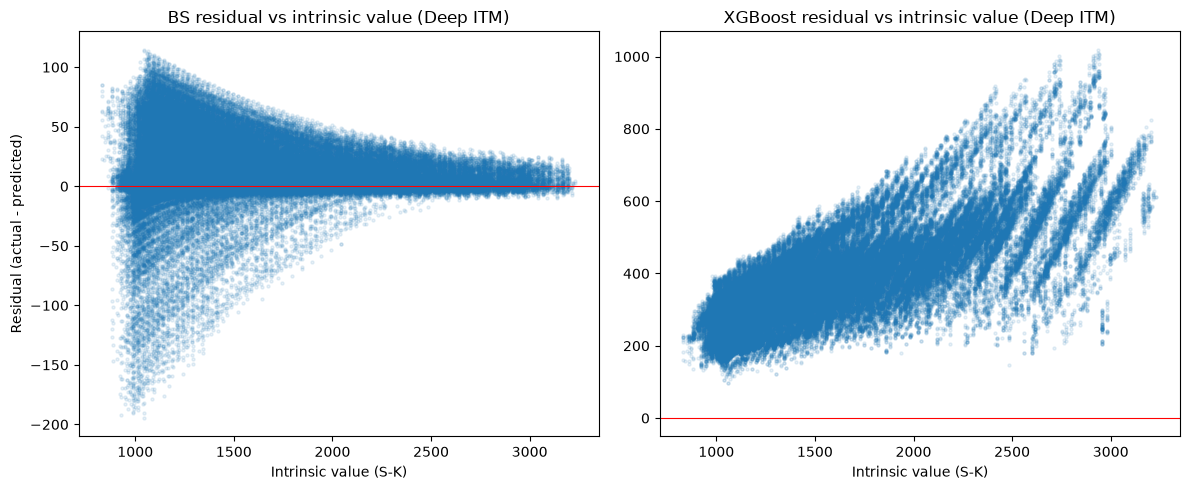

In [80]:
# Visualize: does XGBoost's error grow as intrinsic value grows?
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(deep_itm["intrinsic_value"], deep_itm["bs_residual"], alpha=0.1, s=5)
axes[0].axhline(0, color="red", linewidth=0.8)
axes[0].set_title("BS residual vs intrinsic value (Deep ITM)")
axes[0].set_xlabel("Intrinsic value (S-K)")
axes[0].set_ylabel("Residual (actual - predicted)")

axes[1].scatter(deep_itm["intrinsic_value"], deep_itm["xgb_residual"], alpha=0.1, s=5)
axes[1].axhline(0, color="red", linewidth=0.8)
axes[1].set_title("XGBoost residual vs intrinsic value (Deep ITM)")
axes[1].set_xlabel("Intrinsic value (S-K)")

plt.tight_layout()
plt.show()

## Saving data for graph

In [88]:
print([v for v in dir() if any(k in v.lower() for k in ['model', 'final'])])

['es_model', 'final_model', 'final_n_estimators', 'fold_model', 'model', 'model_v2', 'model_v3', 'model_v4', 'model_v5']


In [91]:
joblib.dump(final_model, "xgb_spx_model.pkl")
print("saved xgboost")

saved xgboost


In [92]:
joblib.dump(model_v5, "xgb_v5_spx_model.pkl")
print("saved v5")

saved v5


## Diebold Mariano test

In [85]:

def diebold_mariano_test(actual, pred1, pred2, loss="squared", lag=None):
    """
    H0: equal predictive accuracy (mean loss differential = 0).
    d = loss(pred1) - loss(pred2): positive d means model 1 has bigger loss (model 2 better).
    """
    e1 = actual - pred1
    e2 = actual - pred2

    if loss == "squared":
        d = e1**2 - e2**2
    elif loss == "absolute":
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("loss must be 'squared' or 'absolute'")

    T = len(d)
    d_mean = d.mean()

    if lag is None:
        lag = int(np.floor(4 * (T / 100) ** (2/9)))

    gamma0 = np.var(d, ddof=0)
    var_d = gamma0
    for k in range(1, lag + 1):
        cov = np.cov(d[:-k], d[k:])[0, 1]
        weight = 1 - k / (lag + 1)
        var_d += 2 * weight * cov

    se_d = np.sqrt(max(var_d, 1e-12) / T)
    dm_stat = d_mean / se_d
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value

In [ ]:
dm_results_bs_vs_xgb = []
for bucket in test_check["moneyness_bucket"].cat.categories: # .cat.categories gives the 7 strings for the buckets
    subset = test_check[test_check["moneyness_bucket"] == bucket] # ex: bucket = "Deep ITM", subset only ~123.621 options Deep ITM AAPL
    dm_stat, p_val = diebold_mariano_test(
        subset["price"].values,
        subset["bs_price"].values,
        subset["xgb_final_pred"].values,
        loss="squared"
    )
    dm_results_bs_vs_xgb.append({
        "bucket": bucket,
        "n": len(subset),
        "dm_stat": dm_stat,
        "p_value": p_val,
        "significant_5pct": p_val < 0.05
    })

dm_bs_vs_xgb_df = pd.DataFrame(dm_results_bs_vs_xgb)
dm_bs_vs_xgb_df